# 04_model_train.ipynb　概要
- 個人住民税予測モデル - Step4: モデル学習・時系列検証
- LightGBM で個人別住民税額を学習し、時系列ホールドアウト（TEST_YEAR）で精度を検証する。
- tax_reform_config.csv の label_correction を適用してから学習する。

## input
- data/03out_individual_prepared.csv  ← 03_feature_eng.py の出力
- config.py                     ← モデル設定（特徴量・パラメータ・学習年・テスト年）
- tax_reform_config.csv         ← 税制改正設定ファイル

## output
- models/lgbm_model.txt              ← LightGBM モデルファイル
- models/model_config.json           ← 特徴量・パラメータ設定（05 が参照）
- data/04out_val_result.csv                ← 個人別予測 vs 実測（TEST_YEAR の out-of-sample）
- data/04out_yearly_result.csv             ← 年度別合算精度
- data/04out_walkforward_result.csv     ← walkforward / retrain_all モード時のみ出力


## 実行モードの設定
NOTEBOOK_ARGS は下部の「notebook実行モードの指定」セクションで指定する（walkforward / retrain-all などモード切替）

## 補足 (定額減税（2024年）の扱い)
teigaku_reduction は active=False に設定済み。

実データを投入する際は、2024年の税額を定額減税前の水準に加工してから 01out_individual_raw.csv に配置する。モデル内での補正は行わない。

---

# ファイルパス設定 / ライブラリインポート

03_notebooks/ から実行してもプロジェクトルート基準の相対パス（data/, models/, tax_reform, config）が解決できるよう、カレントディレクトリをルートへ戻す

In [1]:
import os
import sys
if os.path.basename(os.getcwd()) == "03_notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.join(os.getcwd(), "00_src_settings"))

In [2]:
import argparse
import json
import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib_fontja
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tax_reform import load_reforms, apply_reforms, print_reform_summary, compute_non_taxable_flag
from config import (
    PREPARED_DATA_PATH, MODEL_DIR, MODEL_PATH, MODEL_CONFIG_PATH,
    REFORM_CONFIG_PATH, TRAIN_YEARS, TEST_YEAR,
    FEATURE_COLS, TARGET_COL, LGBM_PARAMS, MIN_TAX,
    VALIDATION_MODE, WF_MIN_TRAIN_YEARS,
)

VAL_PATH    = "data/04out_val_result.csv"
YEARLY_PATH = "data/04out_yearly_result.csv"
WF_PATH     = "data/04out_walkforward_result.csv"

---

## notebook実行モードの指定

このスクリプトは元々 `python 04_model_train.py --walkforward` のようにCLI引数でモードを切り替える設計。
notebook上にはコマンドライン引数がないため、`NOTEBOOK_ARGS` にCLIと同じ文字列のリストを指定することで
`argparse` にそのまま渡す（`main()` 内の `parser.parse_args()` を `parser.parse_args(NOTEBOOK_ARGS)` に変更）。

- `[]`                                : 引数なし実行と同じ（config の `VALIDATION_MODE` に従う）
- `["--standard"]`                    : 標準モード（TRAIN_YEARS → TEST_YEAR の1回評価）
- `["--walkforward"]`                 : ウォークフォワード検証 + 標準最終モデル
- `["--retrain-all"]`                 : ウォークフォワード検証 + 全年度再学習
- `["--walkforward", "--min-train", "3"]` : 最小訓練年数を変更

In [3]:
NOTEBOOK_ARGS = []  # 実行したいモードに応じて上のセルの例のように書き換える

In [4]:
parser = argparse.ArgumentParser()
## 同時に指定できない（排他的な）コマンドライン引数のグループを作成するための argparse のメソッド
mode_group = parser.add_mutually_exclusive_group()
mode_group.add_argument("--walkforward",  action="store_true",
                        help="ウォークフォワード検証 + 標準最終モデル（TRAIN_YEARS）")
mode_group.add_argument("--retrain-all",  action="store_true",
                        help="ウォークフォワード検証 + 全年度（TRAIN+TEST）再学習（実データ推奨）")
mode_group.add_argument("--standard",     action="store_true",
                        help="標準モード（TRAIN_YEARS → TEST_YEAR の 1 回評価）")
parser.add_argument("--min-train", type=int, default=WF_MIN_TRAIN_YEARS,
                    help=f"ウォークフォワードの最小訓練年数（デフォルト: {WF_MIN_TRAIN_YEARS}）")
args = parser.parse_args(NOTEBOOK_ARGS)  # notebook上ではCLI引数の代わりに NOTEBOOK_ARGS を使用

## CLI フラグ > config の VALIDATION_MODE
if args.walkforward:
    mode = "walkforward"
elif args.retrain_all:
    mode = "retrain_all"
elif args.standard:
    mode = "standard"
else:
    mode = VALIDATION_MODE

print(f"=== 04: モデル学習・時系列検証  [{mode}モード] ===")

=== 04: モデル学習・時系列検証  [standardモード] ===


---

# 関数設定

## 精度指標の設定

In [5]:
## 課税者のみの MAPE（非課税者は除外）
def mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true > 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)

## 非課税者(0円)を含む加重平均絶対誤差率。集計誤差率と等価で税収予測の主指標。
def wmape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """非課税者(0円)を含む加重平均絶対誤差率。集計誤差率と等価で税収予測の主指標。"""
    total = np.sum(np.abs(y_true))
    return float(np.sum(np.abs(y_true - y_pred)) / total * 100) if total > 0 else float("nan")


def print_metrics(label: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    mae_val   = mean_absolute_error(y_true, y_pred)
    rmse_val  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val  = mape(y_true, y_pred)
    wmape_val = wmape(y_true, y_pred)
    r2_val    = r2_score(y_true, y_pred)
    print(f"  {label}")
    print(f"    MAE   : {mae_val:>12,.0f} 円")
    print(f"    RMSE  : {rmse_val:>12,.0f} 円")
    print(f"    MAPE  : {mape_val:>8.2f} %  ← 課税者のみ（非課税除外）")
    print(f"    WMAPE : {wmape_val:>8.2f} %  ← 非課税含む・集計誤差率と等価")
    print(f"    R2    : {r2_val:>8.3f}")
    return {"label": label, "MAE": mae_val, "RMSE": rmse_val,
            "MAPE": mape_val, "WMAPE": wmape_val, "R2": r2_val}


def show_feature_importance(model: lgb.LGBMRegressor, feature_cols: list, top_n: int = 10, show: bool = False):
    fi = pd.DataFrame({
        "特徴量": feature_cols,
        "重要度": model.feature_importances_,
    }).sort_values("重要度", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(fi["特徴量"], fi["重要度"], color="steelblue")
    ax.invert_yaxis()  # 重要度1位が上に来るように反転
    ax.set_xlabel("重要度")
    ax.set_title(f"特徴量重要度 Top{top_n}")
    plt.tight_layout()
    if show:
        plt.show()
    plt.close()




## モデル予測に非課税フラグを適用して返す

In [6]:
def _predict_with_nontaxable(
    model: lgb.LGBMRegressor,
    feat_df: pd.DataFrame,
    raw_df: pd.DataFrame,
    feat_cols: list,
) -> np.ndarray:
    ## モデル予測値を取得し、最小税額はMIN_TAX(5300円)となるよう設定
    pred = np.maximum(model.predict(feat_df[feat_cols].fillna(0).values), MIN_TAX)
    _nd  = raw_df["n_dependent"].values if "n_dependent" in raw_df.columns \
        else (raw_df["deduct_dependent"].values / 330_000).round().astype(int)
    ## tax_reform.py より関数を読み込み、非課税フラグを計算
    _fl  = compute_non_taxable_flag(
        raw_df["income_total"].values, _nd,
        (raw_df["deduct_spouse"].values > 0).astype(int),
    )
    return np.where(_fl, 0, pred)

## ウォークフォワード検証(時系列フォールド検証を実行する)

In [7]:
def run_walkforward_folds(
    df: pd.DataFrame,
    df_corrected: pd.DataFrame,
    feat_cols: list,
    min_train: int = WF_MIN_TRAIN_YEARS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ## 各年tについて「tより前の年」をtrain候補にし、その数がmin_train（=2）以上ある年だけ採用
    all_years = sorted(df["year"].unique().tolist())
    folds = [
        ([y for y in all_years if y < t], t)
        for t in all_years
        if len([y for y in all_years if y < t]) >= min_train
    ]

    print(f"── ウォークフォワード検証（{len(folds)} フォールド / 最小訓練年数: {min_train}）──")
    results       = []
    last_fold_preds = pd.DataFrame()

    for train_years, test_year in folds:
        tr_df  = df_corrected[df_corrected["year"].isin(train_years)].reset_index(drop=True)
        te_df  = df_corrected[df_corrected["year"] == test_year].reset_index(drop=True)
        te_raw = df[df["year"] == test_year].reset_index(drop=True)

        m = lgb.LGBMRegressor(**LGBM_PARAMS)
        m.fit(
            tr_df[feat_cols].fillna(0).values,
            tr_df[TARGET_COL].values,
            callbacks=[lgb.log_evaluation(period=-1)],
        )

        pred   = _predict_with_nontaxable(m, te_df, te_raw, feat_cols)
        actual = te_raw[TARGET_COL].values

        ## 実測合計・予測合計・誤差率・MAPE を計算（億円単位）
        act_b  = actual.sum() / 1e8
        prd_b  = pred.sum()   / 1e8
        err_r  = (prd_b - act_b) / act_b * 100
        mape_v = mape(actual, pred)

        tag = "  ← 本番テスト年と同条件" if test_year == TEST_YEAR else ""
        print(f"  train={train_years[0]}〜{train_years[-1]} → test={test_year}:  "
              f"実測 {act_b:.2f}億 / 予測 {prd_b:.2f}億 / 誤差率 {err_r:+.2f}%  "
              f"個人MAPE {mape_v:.1f}%{tag}")

        results.append({
            "train_years"    : "|".join(str(y) for y in train_years),
            "test_year"      : test_year,
            "n_train"        : len(tr_df),
            "n_test"         : len(te_df),
            "actual_oku"     : round(act_b, 2), # 億円単位(小数点2桁で丸める)
            "pred_oku"       : round(prd_b, 2),
            "agg_error_pct"  : round(err_r, 2),
            "individual_mape": round(mape_v, 2),
        })

        ## 最終フォールド（test=TEST_YEAR）の個人別予測を保持
        if test_year == TEST_YEAR:
            last_fold_preds = te_raw[["person_id", "year", TARGET_COL]].copy()
            last_fold_preds["pred_tax"] = pred.round(0).astype(int)
            last_fold_preds["error"]    = last_fold_preds["pred_tax"] - last_fold_preds[TARGET_COL]

    fold_summary = pd.DataFrame(results)
    avg_err = fold_summary["agg_error_pct"].mean()
    std_err = fold_summary["agg_error_pct"].std()
    print(f"\n  平均誤差率: {avg_err:+.2f}%  標準偏差: {std_err:.2f}%")
    if std_err < 1.5:
        print("  → フォールド間で安定（標準偏差 < 1.5%）")
    else:
        print("  → フォールド間で不安定（標準偏差 ≥ 1.5%）：特徴量または年度補正を見直すこと")
    if abs(avg_err) < 1.0:
        print("  → 系統的バイアスなし（平均誤差率 ±1%以内）")
    elif avg_err > 0:
        print(f"  → 全フォールドで過大予測傾向（平均 {avg_err:+.2f}%）")
    else:
        print(f"  → 全フォールドで過小予測傾向（平均 {avg_err:+.2f}%）")
    print()

    fold_summary.to_csv(WF_PATH, index=False, encoding="utf-8-sig")
    print(f"  → {WF_PATH} にウォークフォワード結果を保存\n")
    return fold_summary, last_fold_preds

---

# 前処理

## データ読込・特徴量列の確認

In [8]:
os.makedirs(MODEL_DIR, exist_ok=True)

## config.py から PREPARED_DATA_PATH = "data/03out_individual_prepared.csv"
print(f"データ読込: {PREPARED_DATA_PATH}")
df = pd.read_csv(PREPARED_DATA_PATH, encoding="utf-8-sig")
print(f"  {len(df):,} 件 / {df['year'].nunique()} 年分")

feat_cols = [c for c in FEATURE_COLS if c in df.columns]
missing   = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"  ! 列なし（スキップ）: {missing}")
df[feat_cols] = df[feat_cols].fillna(0)

データ読込: data/individual_prepared.csv


  597,000 件 / 6 年分


## 税制改正補正（学習ラベルへの反映）

In [9]:
# ── 税制改正補正（学習ラベル） ───────────────────────────────────────────
## config.py から REFORM_CONFIG_PATH = "data/tax_reform_config.csv"
print("── 税制改正補正（label_correction） ──")

reforms = load_reforms(
    REFORM_CONFIG_PATH,
    target_year=max(TRAIN_YEARS + [TEST_YEAR]),
    reform_type="label_correction",
)
print_reform_summary(reforms)
df_corrected = apply_reforms(df.copy(), reforms)

if reforms:
    for r in reforms:
        yr = r["params"]["_effective_year"]
        if yr in df["year"].values:
            orig = df[df["year"] == yr][TARGET_COL].mean() / 1e4
            corr = df_corrected[df_corrected["year"] == yr][TARGET_COL].mean() / 1e4
            print(f"  {yr}年 平均税額: 補正前 {orig:.1f}万円 → 補正後 {corr:.1f}万円")

── 税制改正補正（label_correction） ──
  適用する補正なし


---

# 実行

## ウォークフォワード検証の実行（walkforward / retrain_all モードのみ）

In [10]:
last_fold_preds = pd.DataFrame()
if mode in ("walkforward", "retrain_all"):
    _, last_fold_preds = run_walkforward_folds(
        df, df_corrected, feat_cols, min_train=args.min_train
    )

## 最終モデルの学習

In [11]:
# ── 最終モデルの訓練年度を決定 ────────────────────────────────────────────
if mode == "retrain_all":
    final_train_years = TRAIN_YEARS + [TEST_YEAR]
    print(f"── 最終モデル学習（全年度 {final_train_years[0]}〜{final_train_years[-1]}）──")
    print(f"  ※ {TEST_YEAR}年は訓練に含まれるため in-sample。精度評価はウォークフォワードを参照。")
else:
    final_train_years = TRAIN_YEARS
    print(f"── 最終モデル学習 ──")

# おためし
print(f"  final_train_years:{final_train_years}")

train_df = df_corrected[df_corrected["year"].isin(final_train_years)].reset_index(drop=True)
print(f"  訓練: {len(train_df):,} 件（{final_train_years[0]}〜{final_train_years[-1]}年・label補正済）")

model = lgb.LGBMRegressor(**LGBM_PARAMS)
print("学習中... (LightGBM)")
model.fit(
    train_df[feat_cols].values,
    train_df[TARGET_COL].values,
    callbacks=[lgb.log_evaluation(period=-1)],
)
print("完了")

── 最終モデル学習 ──
  final_train_years:[2020, 2021, 2022, 2023, 2024]


  訓練: 498,200 件（2020〜2024年・label補正済）
学習中... (LightGBM)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.398485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10467
[LightGBM] [Info] Number of data points in the train set: 498200, number of used features: 62
[LightGBM] [Info] Start training from score 182311.460755


完了


---

# 評価

## 訓練データ精度の評価（過学習チェック）

In [12]:
# ── 訓練データ精度（過学習チェック） ─────────────────────────────────────
print(f"── 訓練データ精度（{final_train_years[0]}〜{final_train_years[-1]}年） ──")
pred_train    = _predict_with_nontaxable(model, train_df, train_df, feat_cols)
metrics_train = print_metrics("訓練データ（label補正済）", train_df[TARGET_COL].values, pred_train)

── 訓練データ精度（2020〜2024年） ──


  訓練データ（label補正済）
    MAE   :          905 円
    RMSE  :        2,227 円
    MAPE  :     1.61 %  ← 課税者のみ（非課税除外）
    WMAPE :     0.50 %  ← 非課税含む・集計誤差率と等価
    R2    :    1.000


## テストデータ精度の評価と過学習判定

In [13]:
# ── 個人レベル精度（テスト年度の評価） ───────────────────────────────────
if mode == "retrain_all" and not last_fold_preds.empty:
    ## retrain_all: fold4 の out-of-sample 予測を評価（train=2020-2024, test=2025）
    print(f"── 個人レベル精度（ウォークフォワード最終フォールド: train={TRAIN_YEARS[0]}〜{TRAIN_YEARS[-1]} → test={TEST_YEAR}）──")
    y_test    = last_fold_preds[TARGET_COL].values
    pred_test = last_fold_preds["pred_tax"].values.astype(float)
    metrics_test = print_metrics(f"最終フォールド out-of-sample（{TEST_YEAR}年）", y_test, pred_test)
else:
    print(f"── 個人レベル精度（テスト年 = {TEST_YEAR}年） ──")
    test_df     = df_corrected[df_corrected["year"] == TEST_YEAR].reset_index(drop=True)
    test_df_raw = df[df["year"] == TEST_YEAR].reset_index(drop=True)
    pred_test   = _predict_with_nontaxable(model, test_df, test_df_raw, feat_cols)
    y_test      = test_df_raw[TARGET_COL].values
    metrics_test = print_metrics("テストデータ（実測値）", y_test, pred_test)

ratio = metrics_test["MAE"] / metrics_train["MAE"] if metrics_train["MAE"] > 0 else float("inf")
if mode == "retrain_all":
    print(f"\n  ※ retrain_all モード: 訓練精度は 2020〜2025 in-sample、テスト精度は fold4 out-of-sample。")
elif ratio > 2.0:
    print(f"\n  訓練/テスト MAE 比: [!] 過学習の疑い（訓練の {ratio:.1f}x）")
elif ratio > 1.5:
    print(f"\n  訓練/テスト MAE 比: [~] やや過学習気味（訓練の {ratio:.1f}x）")
else:
    print(f"\n  訓練/テスト MAE 比: [OK] 過学習なし（訓練の {ratio:.1f}x）")

── 個人レベル精度（テスト年 = 2025年） ──


  テストデータ（実測値）
    MAE   :        1,072 円
    RMSE  :        3,802 円
    MAPE  :     1.35 %  ← 課税者のみ（非課税除外）
    WMAPE :     0.55 %  ← 非課税含む・集計誤差率と等価
    R2    :    1.000

  訓練/テスト MAE 比: [OK] 過学習なし（訓練の 1.2x）


## 年度別合算精度の評価

In [14]:
# ── 年度別合算精度 ─────────────────────────────────────────────
print("── 年度別合算精度 ──")
yearly_rows  = []
reform_years = {r["params"]["_effective_year"] for r in reforms}
show_years   = final_train_years if mode == "retrain_all" else TRAIN_YEARS + [TEST_YEAR]

for yr in show_years:
    yr_raw  = df[df["year"] == yr].reset_index(drop=True)
    yr_corr = df_corrected[df_corrected["year"] == yr].reset_index(drop=True)
    p_yr    = _predict_with_nontaxable(model, yr_corr, yr_raw, feat_cols)
    y_yr    = yr_raw[TARGET_COL].values
    act_b   = y_yr.sum() / 1e8
    prd_b   = p_yr.sum() / 1e8
    err_r   = (prd_b - act_b) / act_b * 100
    note    = "（補正年）" if yr in reform_years else ""
    is_test = yr == TEST_YEAR
    if mode == "retrain_all" and is_test:
        tag = "← in-sample（訓練込み）"
    elif is_test:
        tag = "← TEST"
    else:
        tag = ""
    print(f"  {yr}年: 実測 {act_b:.2f}億 / 予測 {prd_b:.2f}億 / 誤差率 {err_r:+.2f}%  {tag}{note}")
    yearly_rows.append({
        "year"           : yr,
        "actual_oku"     : round(act_b, 2),
        "pred_oku"       : round(prd_b, 2),
        "error_rate_pct" : round(err_r, 2),
        "is_test"        : is_test,
        "label_corrected": yr in reform_years,
        "in_sample"      : mode == "retrain_all" and is_test,
    })

── 年度別合算精度 ──


  2020年: 実測 177.05億 / 予測 177.03億 / 誤差率 -0.01%  


  2021年: 実測 182.00億 / 予測 181.95億 / 誤差率 -0.03%  


  2022年: 実測 180.18億 / 予測 180.21億 / 誤差率 +0.02%  


  2023年: 実測 182.31億 / 予測 182.33億 / 誤差率 +0.01%  


  2024年: 実測 186.73億 / 予測 186.74億 / 誤差率 +0.00%  


  2025年: 実測 193.31億 / 予測 193.31億 / 誤差率 +0.00%  ← TEST


## 特徴量重要度の可視化

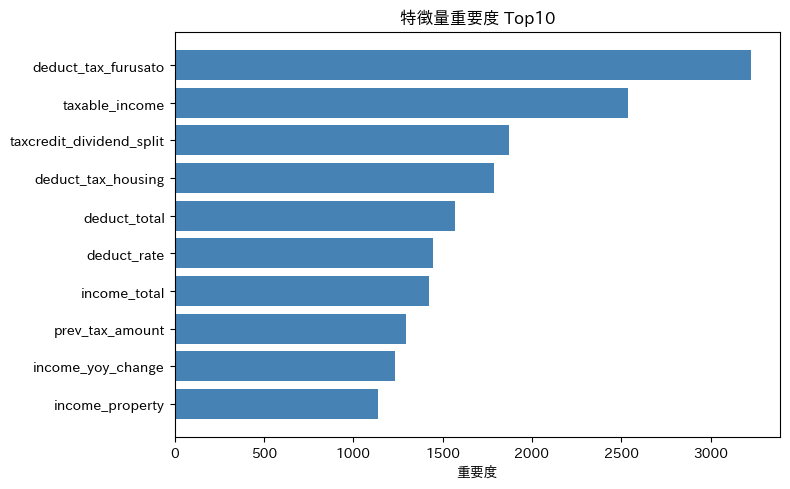

In [15]:
show_feature_importance(model, feat_cols, show=True)

---

# 結果の保存

## 個人別予測結果の保存（04out_val_result.csv）

In [16]:
# ── 04out_val_result.csv の保存 ─────────────────────────────────────────────────
if mode == "retrain_all" and not last_fold_preds.empty:
    ## fold4 の out-of-sample 予測をそのまま保存
    last_fold_preds.to_csv(VAL_PATH, index=False, encoding="utf-8-sig")
else:
    ## standard / walkforward: 最終モデルの TEST_YEAR 予測を保存
    test_df     = df_corrected[df_corrected["year"] == TEST_YEAR].reset_index(drop=True)
    test_df_raw = df[df["year"] == TEST_YEAR].reset_index(drop=True)
    pred_test_final = _predict_with_nontaxable(model, test_df, test_df_raw, feat_cols)
    result_df       = test_df_raw[["person_id", "year", TARGET_COL]].copy()
    result_df["pred_tax"] = pred_test_final.round(0).astype(int)
    result_df["error"]    = result_df["pred_tax"] - result_df[TARGET_COL]
    result_df.to_csv(VAL_PATH, index=False, encoding="utf-8-sig")
print(f"→ {VAL_PATH} に個人別検証結果を保存")

→ data/val_result.csv に個人別検証結果を保存


## モデル・設定・年度別結果の保存

In [17]:
# ── CSV・モデル保存 ──────────────────────────────────────────────────────
## 04_model_train.py で定義 : YEARLY_PATH = "data/04out_yearly_result.csv"
pd.DataFrame(yearly_rows).to_csv(YEARLY_PATH, index=False, encoding="utf-8-sig")
print(f"→ {YEARLY_PATH} に年度別合算精度を保存")

## config.py で設定 MODEL_CONFIG_PATH  = "models/model_config.json"
model_config = {
    "feature_cols": feat_cols,
    "train_years": final_train_years,
    "test_year": TEST_YEAR,
    "lgbm_params": {
        "n_estimators": LGBM_PARAMS["n_estimators"],
        "learning_rate": LGBM_PARAMS["learning_rate"],
        "num_leaves": LGBM_PARAMS["num_leaves"],
        "min_child_samples": LGBM_PARAMS["min_child_samples"],
        "random_state": LGBM_PARAMS["random_state"],
        "n_jobs": LGBM_PARAMS["n_jobs"],
    },
    "min_tax": MIN_TAX,
    "reform_config": REFORM_CONFIG_PATH,
    "validation_mode": mode,
}
with open(MODEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)
print(f"→ {MODEL_CONFIG_PATH} に設定を保存")

model.booster_.save_model(MODEL_PATH)
print(f"→ {MODEL_PATH} にモデルを保存（訓練: {final_train_years[0]}〜{final_train_years[-1]}年）")

print("\n次: python 05_predict_2026.py")

→ data/yearly_result.csv に年度別合算精度を保存
→ models/model_config.json に設定を保存


→ models/lgbm_model.txt にモデルを保存（訓練: 2020〜2024年）

次: python 05_predict_2026.py
